# Важность степени/порядка EGM2008 для оптимизированной привязки N2

Этот ноутбук сравнивает несколько уровней усечения EGM2008 в той же оптимизации привязки N2, что используется в `4_trajectory_tie_in_optimization_N2_mipt_forces.ipynb`. Каждый вариант `(degree, order)` независимо оптимизируется для каждого спутника с использованием тех же локальных эталонных состояний и постановки least-squares.

In [13]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
REPO_URL = 'https://github.com/Gavr101/space_modeling.git'


def run(cmd):
    print('>>', ' '.join(map(str, cmd)))
    subprocess.check_call(cmd)


def find_project_root(start):
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'dynamics').is_dir() and (candidate / 'visualization').is_dir():
            return candidate
    raise RuntimeError(f'Cannot find project root from {start}')


if IN_COLAB:
    PROJECT_ROOT = Path('/content/space_modeling')
    if not PROJECT_ROOT.exists():
        run(['git', 'clone', REPO_URL, str(PROJECT_ROOT)])
    os.chdir(PROJECT_ROOT)
    run([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pip'])
    run([sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt'])
    run([sys.executable, '-m', 'pip', 'install', '-e', '.'])
else:
    PROJECT_ROOT = find_project_root(Path.cwd())
    os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('Working dir:', PROJECT_ROOT)

Working dir: C:\Users\Gavriil\VS_projects\space_modeling


In [14]:
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
from astropy.coordinates import GCRS, ITRS, CartesianRepresentation
from dataclasses import replace
from scipy.optimize import least_squares

from dynamics.eof import read_sentinel_eof
from dynamics.force_models import ForceModelConfig
from dynamics.propagator import PropagationConfig, SpacecraftProperties, propagate_orbit
from dynamics.sp3 import download_sp3, itrs_states_to_gcrs, read_sp3, sp3_velocity_records


## Конфигурация эксперимента

Базовая силовая модель повторяет `4_trajectory_tie_in_optimization_N2_mipt_forces.ipynb`: включены гравитация EGM2008, сопротивление NRLMSISE-00, третьи тела Солнце/Луна и SRP. Изменяемые параметры - `gravity_max_degree` и `gravity_max_order`. Веса измерений являются ковариационными допущениями для целевой функции least-squares, а не случайными возмущениями исторических состояний.

In [15]:
EARTH_RADIUS_M = 6_378_137.0
EARTH_MU_M3_S2 = 3.986004418e14
DATA_DIR = PROJECT_ROOT / 'data'

CROSSING_MODE = 'latitude'  # 'latitude' or 'longitude'
TARGET_LATITUDE_DEG = 67.5641
TARGET_LONGITUDE_DEG = 67.5641
CROSSING_DIRECTION = 'ascending'  # Same direction gives roughly one orbit between consecutive crossings.
N_MEASUREMENTS = 2
LAST_CROSSING_AFTER_H = 6.0
ORBIT_PERIOD_REL_TOL = 0.25

FORECAST_HOURS = 12.0
PROPAGATION_STEP_SECONDS = 120.0
REFERENCE_DURATION_HOURS = LAST_CROSSING_AFTER_H + FORECAST_HOURS + 4.0

# Эти сигмы являются ковариационными допущениями для исторических измерений, а не случайным шумом.
# Последнее измерение задаёт t = 0 и закрепляется жёстче, чтобы избежать большой
# невязки оптимизированного прогноза в начальной точке.
POSITION_OBSERVATION_SIGMA_M = 50.0
VELOCITY_OBSERVATION_SIGMA_M_S = 1.0
LAST_MEASUREMENT_OBSERVATION_SCALE = 0.2
PARAMETER_LOG_SIGMA = np.log(1.5)
PARAMETER_MULTIPLIER_BOUNDS = (0.2, 5.0)
MAX_NFEV = 35

OPTIMIZED_PARAMETER_GROUPS = {
    'coordinates': True,
    'velocities': True,
    'spacecraft_parameters': True,
}

VELOCITY_REFERENCE_SOURCES = {
    'Sentinel-1A': {
        'format': 'sentinel_eof',
        'url': 'https://s1-orbits.s3.us-west-2.amazonaws.com/AUX_POEORB/S1A_OPER_AUX_POEORB_OPOD_20230821T080724_V20230731T225942_20230802T005942.EOF',
        'path': DATA_DIR / 'eof' / 'S1A_OPER_AUX_POEORB_OPOD_20230821T080724_V20230731T225942_20230802T005942.EOF',
        'spacecraft': SpacecraftProperties(mass=2185.0, cd=2.2, cr=1.3, reference_area=10.3),
    },
    'Sentinel-1B': {
        'format': 'sentinel_eof',
        'url': 'https://s1-orbits.s3.us-west-2.amazonaws.com/AUX_POEORB/S1B_OPER_AUX_POEORB_OPOD_20210203T112353_V20210113T225942_20210115T005942.EOF',
        'path': DATA_DIR / 'eof' / 'S1B_OPER_AUX_POEORB_OPOD_20210203T112353_V20210113T225942_20210115T005942.EOF',
        'spacecraft': SpacecraftProperties(mass=2185.0, cd=2.2, cr=1.3, reference_area=10.3),
    },
    'CASSIOPE / Swarm-E': {
        'format': 'sp3',
        'satellite_id': 'L63',
        'url': 'https://epop-data.phys.ucalgary.ca/2017/02/01/CAS_Orbit_GEO_20170201T000000_20170201T235959_1.1.0.sp3.zip',
        'path': DATA_DIR / 'sp3' / 'CAS_Orbit_GEO_20170201T000000_20170201T235959_1.1.0.sp3.zip',
        'spacecraft': SpacecraftProperties(mass=500.0, cd=2.2, cr=1.3, reference_area=2.2),
    },
    'Swarm B': {
        'format': 'sp3',
        'satellite_id': 'L48',
        'url': 'https://swarm-diss.eo.esa.int/?do=download&file=swarm%2FLevel2daily%2FLatest_baselines%2FPOD%2FRD%2FSat_B%2FSW_OPER_SP3BCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'path': DATA_DIR / 'sp3' / 'SW_OPER_SP3BCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'spacecraft': SpacecraftProperties(mass=438.0, cd=2.2, cr=1.3, reference_area=1.1),
    },
    'Swarm C': {
        'format': 'sp3',
        'satellite_id': 'L49',
        'url': 'https://swarm-diss.eo.esa.int/?do=download&file=swarm%2FLevel2daily%2FLatest_baselines%2FPOD%2FRD%2FSat_C%2FSW_OPER_SP3CCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'path': DATA_DIR / 'sp3' / 'SW_OPER_SP3CCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'spacecraft': SpacecraftProperties(mass=438.0, cd=2.2, cr=1.3, reference_area=1.1),
    },
    'Swarm A': {
        'format': 'sp3',
        'satellite_id': 'L47',
        'url': 'https://swarm-diss.eo.esa.int/?do=download&file=swarm%2FLevel2daily%2FLatest_baselines%2FPOD%2FRD%2FSat_A%2FSW_OPER_SP3ACOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'path': DATA_DIR / 'sp3' / 'SW_OPER_SP3ACOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'spacecraft': SpacecraftProperties(mass=438.0, cd=2.2, cr=1.3, reference_area=1.1),
    },
}

# Ручное управление временем выполнения: сократите этот список для быстрых smoke-прогонов.
RUN_SATELLITES = list(VELOCITY_REFERENCE_SOURCES)

DATA_DIR = PROJECT_ROOT / 'data'
CACHE_DIR = DATA_DIR / 'cache'
SPACE_WEATHER_FILE = CACHE_DIR / 'SW-All.csv'
EGM2008_FILE = CACHE_DIR / 'egm2008.gfc'

INTEGRATOR = 'dop853'
RTOL = 3e-9
ATOL = np.array([1e-2, 1e-2, 1e-2, 1e-5, 1e-5, 1e-5], dtype=float)


## Загрузка исходных эталонных данных

Эксперимент использует исходные исторические записи, а не пересэмплированную эталонную сетку. Состояния EOF и SP3 преобразуются из ITRS в GCRS в исходные эпохи, а все последующие сравнения используют ближайшие исходные отсчёты.

In [16]:
def download_reference_file(source):
    return download_sp3(source['url'], source['path'])


def load_native_reference(source, duration_hours):
    """Load native historical states and convert them to GCRS without resampling."""
    path = download_reference_file(source)
    if source['format'] == 'sentinel_eof':
        orbit = read_sentinel_eof(path)
        epochs = orbit.epochs
        positions_itrs_m = orbit.positions_m
        velocities_itrs_m_s = orbit.velocities_m_s
    elif source['format'] == 'sp3':
        orbit = read_sp3(path)
        satellite_id = source['satellite_id']
        velocity_records = sp3_velocity_records(orbit)
        if satellite_id not in orbit.positions_m or satellite_id not in velocity_records:
            raise ValueError(f'{path.name} does not contain native position/velocity records for {satellite_id}.')
        epochs = orbit.epochs
        positions_itrs_m = orbit.positions_m[satellite_id]
        velocities_itrs_m_s = velocity_records[satellite_id]
    else:
        raise ValueError(f'Unsupported reference format: {source["format"]}')

    finite_mask = np.all(np.isfinite(positions_itrs_m), axis=1) & np.all(np.isfinite(velocities_itrs_m_s), axis=1)
    epochs = epochs[finite_mask]
    positions_itrs_m = positions_itrs_m[finite_mask]
    velocities_itrs_m_s = velocities_itrs_m_s[finite_mask]

    elapsed_s = (epochs - epochs[0]).sec
    keep = elapsed_s <= duration_hours * 3600.0
    epochs = epochs[keep]
    elapsed_s = elapsed_s[keep]
    positions_itrs_m = positions_itrs_m[keep]
    velocities_itrs_m_s = velocities_itrs_m_s[keep]

    positions_gcrs_m, velocities_gcrs_m_s = itrs_states_to_gcrs(epochs, positions_itrs_m, velocities_itrs_m_s)
    states = np.column_stack((positions_gcrs_m, velocities_gcrs_m_s))
    if states.shape[0] < 3:
        raise ValueError(f'Not enough native states in {path}.')
    return path, epochs, elapsed_s, states


def median_altitude_km(states):
    return float(np.median(np.linalg.norm(states[:, :3], axis=1) - EARTH_RADIUS_M) / 1000.0)


def nearest_states(source_seconds, states, target_seconds):
    """Return states from the nearest available native historical samples."""
    source_seconds = np.asarray(source_seconds, dtype=float)
    target_seconds = np.asarray(target_seconds, dtype=float)
    insertion_idx = np.searchsorted(source_seconds, target_seconds)
    right_idx = np.clip(insertion_idx, 0, len(source_seconds) - 1)
    left_idx = np.clip(insertion_idx - 1, 0, len(source_seconds) - 1)
    use_right = np.abs(source_seconds[right_idx] - target_seconds) < np.abs(target_seconds - source_seconds[left_idx])
    nearest_idx = np.where(use_right, right_idx, left_idx)
    return states[nearest_idx], nearest_idx

## Выбор пересечений

Пересечение определяется по смене знака ошибки широты или долготы. Выбранное измерение - ближайшая исходная историческая запись к оценке этого события. При `CROSSING_DIRECTION = 'ascending'` последовательные выбранные пересечения должны соответствовать последовательным виткам орбиты, а не чередованию восходящего/нисходящего участка через полвитка.

In [17]:
def gcrs_positions_to_geodetic(epochs, positions_gcrs_m):
    representation = CartesianRepresentation(
        x=positions_gcrs_m[:, 0] * u.m,
        y=positions_gcrs_m[:, 1] * u.m,
        z=positions_gcrs_m[:, 2] * u.m,
    )
    gcrs = GCRS(representation, obstime=epochs)
    itrs = gcrs.transform_to(ITRS(obstime=epochs))
    spherical = itrs.spherical
    longitude_deg = spherical.lon.wrap_at(180 * u.deg).deg
    latitude_deg = spherical.lat.deg
    altitude_m = spherical.distance.to_value(u.m) - EARTH_RADIUS_M
    return latitude_deg, longitude_deg, altitude_m


def wrapped_longitude_delta_deg(longitudes_deg, target_deg):
    return ((longitudes_deg - target_deg + 180.0) % 360.0) - 180.0


def find_line_crossings(epochs, source_seconds, states):
    lat_deg, lon_deg, alt_m = gcrs_positions_to_geodetic(epochs, states[:, :3])
    if CROSSING_MODE == 'latitude':
        values = lat_deg - TARGET_LATITUDE_DEG
        target_label = f'{TARGET_LATITUDE_DEG:.4f} deg latitude'
    elif CROSSING_MODE == 'longitude':
        values = wrapped_longitude_delta_deg(lon_deg, TARGET_LONGITUDE_DEG)
        target_label = f'{TARGET_LONGITUDE_DEG:.4f} deg longitude'
    else:
        raise ValueError("CROSSING_MODE must be 'latitude' or 'longitude'.")

    crossings = []
    used_indices = set()
    for i in range(len(values) - 1):
        if values[i] == 0.0:
            alpha = 0.0
        elif values[i] * values[i + 1] > 0.0:
            continue
        else:
            alpha = abs(values[i]) / (abs(values[i]) + abs(values[i + 1]))

        slope = values[i + 1] - values[i]
        if CROSSING_DIRECTION == 'ascending' and slope <= 0.0:
            continue
        if CROSSING_DIRECTION == 'descending' and slope >= 0.0:
            continue

        event_s = source_seconds[i] + alpha * (source_seconds[i + 1] - source_seconds[i])
        nearest_idx = i if abs(source_seconds[i] - event_s) <= abs(source_seconds[i + 1] - event_s) else i + 1
        if nearest_idx in used_indices:
            continue
        used_indices.add(nearest_idx)
        crossings.append({
            'source_seconds': float(source_seconds[nearest_idx]),
            'event_source_seconds': float(event_s),
            'source_index': int(nearest_idx),
            'epoch': epochs[nearest_idx],
            'state': states[nearest_idx].copy(),
            'latitude_deg': float(lat_deg[nearest_idx]),
            'longitude_deg': float(lon_deg[nearest_idx]),
            'altitude_m': float(alt_m[nearest_idx]),
            'direction': 'ascending' if slope > 0.0 else 'descending',
            'target_label': target_label,
        })
    return crossings


def estimate_kepler_period_s(state):
    """Estimate orbital period [s] from two-body specific mechanical energy."""
    r = np.linalg.norm(state[:3])
    v2 = float(np.dot(state[3:], state[3:]))
    inv_a = 2.0 / r - v2 / EARTH_MU_M3_S2
    if inv_a <= 0.0:
        return np.nan
    semi_major_axis_m = 1.0 / inv_a
    return 2.0 * np.pi * np.sqrt(semi_major_axis_m**3 / EARTH_MU_M3_S2)


def select_measurements(crossings):
    """Select N consecutive same-direction crossings and check each interval is one orbit."""
    if N_MEASUREMENTS < 2:
        raise ValueError('N_MEASUREMENTS must be at least 2 for a tie-in experiment.')

    eligible_last = [i for i, c in enumerate(crossings) if c['source_seconds'] >= LAST_CROSSING_AFTER_H * 3600.0]
    if not eligible_last:
        raise RuntimeError('No crossing found after LAST_CROSSING_AFTER_H; increase REFERENCE_DURATION_HOURS.')

    last_idx = eligible_last[0]
    first_idx = last_idx - (N_MEASUREMENTS - 1)
    if first_idx < 0:
        raise RuntimeError('Not enough previous same-direction crossings; lower LAST_CROSSING_AFTER_H or N_MEASUREMENTS.')

    selected = crossings[first_idx:last_idx + 1]
    measurement_times_s = np.array([c['source_seconds'] for c in selected], dtype=float)
    interval_dt_s = np.diff(measurement_times_s)
    period_s = np.array([estimate_kepler_period_s(c['state']) for c in selected[1:]], dtype=float)
    rel_errors = np.abs(interval_dt_s - period_s) / period_s

    if np.any(~np.isfinite(period_s)):
        raise RuntimeError('Could not estimate Kepler periods for the selected measurements.')
    if np.any(rel_errors > ORBIT_PERIOD_REL_TOL):
        details = ', '.join(
            f'dt={dt / 60.0:.2f} min vs period={period / 60.0:.2f} min ({err:.2%})'
            for dt, period, err in zip(interval_dt_s, period_s, rel_errors)
        )
        raise RuntimeError(f'Selected consecutive measurements are not one orbit apart: {details}.')

    return selected, period_s, rel_errors


## Вспомогательные функции least-squares для привязки

Вектор решения разделён на три отключаемые группы: коррекция начального положения, коррекция начальной скорости и нестатусные параметры модели. Отключение группы удаляет её из вектора решения и из соответствующего блока априорных невязок.

Сама модель траектории теперь является одной задачей Коши: оптимизатор меняет только состояние в первом измерении и включённые параметры модели, распространяет одну непрерывную траекторию через все эпохи измерений и сравнивает распространённые состояния с измерениями. Третья группа содержит `Cd*A/m`, когда включено атмосферное сопротивление, `Cr*A/m`, когда включено SRP или изотропное ИК-излучение Земли, а также опциональные масштабные коэффициенты сил из `EnvironmentConfig.force_scale_factors` для включённых гармоник гравитации, возмущений третьих тел Солнце/Луна, релятивистской поправки и приливов твёрдой Земли. Центральная сферическая гравитация Земли намеренно не масштабируется.

In [18]:
def observation_sigmas_for_measurements(n_measurements):
    """Return per-measurement state sigmas in SI units: [m, m, m, m/s, m/s, m/s]."""
    sigmas = np.tile(
        np.array(
            [
                POSITION_OBSERVATION_SIGMA_M,
                POSITION_OBSERVATION_SIGMA_M,
                POSITION_OBSERVATION_SIGMA_M,
                VELOCITY_OBSERVATION_SIGMA_M_S,
                VELOCITY_OBSERVATION_SIGMA_M_S,
                VELOCITY_OBSERVATION_SIGMA_M_S,
            ],
            dtype=float,
        ),
        (n_measurements, 1),
    )
    sigmas[-1, :] *= LAST_MEASUREMENT_OBSERVATION_SCALE
    return sigmas


def ballistic_coefficients_from_spacecraft(spacecraft):
    """Return force coefficients that the propagator uses through SpacecraftProperties.

    Units:
    - drag_ballistic_coefficient_m2_kg = Cd * A / m [m^2/kg]
    - radiation_pressure_coefficient_m2_kg = Cr * A / m [m^2/kg]
    """
    area_to_mass = spacecraft.reference_area / spacecraft.mass
    return {
        'drag_ballistic_coefficient_m2_kg': spacecraft.cd * area_to_mass,
        'radiation_pressure_coefficient_m2_kg': spacecraft.cr * area_to_mass,
    }


def active_spacecraft_parameter_specs(force_models, spacecraft_prior):
    """Return non-state coefficients that are identifiable for enabled force models."""
    prior = ballistic_coefficients_from_spacecraft(spacecraft_prior)
    specs = []
    if force_models.atmospheric_drag:
        specs.append({
            'name': 'drag_ballistic_coefficient_m2_kg',
            'label': 'Cd*A/m drag [m^2/kg]',
            'prior': prior['drag_ballistic_coefficient_m2_kg'],
            'kind': 'ballistic_coefficient',
        })
    if force_models.solar_radiation_pressure or force_models.earth_radiation_model != 'none':
        specs.append({
            'name': 'radiation_pressure_coefficient_m2_kg',
            'label': 'Cr*A/m radiation [m^2/kg]',
            'prior': prior['radiation_pressure_coefficient_m2_kg'],
            'kind': 'ballistic_coefficient',
        })
    if force_models.spherical_earth_gravity and force_models.earth_gravity_model == 'j2' and force_models.earth_j2:
        specs.append({'name': 'j2', 'label': 'J2 perturbation scale', 'prior': 1.0, 'kind': 'force_scale'})
    if force_models.spherical_earth_gravity and force_models.earth_gravity_model == 'egm2008':
        specs.append({'name': 'gravity_harmonics', 'label': 'gravity harmonics scale', 'prior': 1.0, 'kind': 'force_scale'})
    if force_models.third_body_sun:
        specs.append({'name': 'third_body_sun', 'label': 'Sun third-body scale', 'prior': 1.0, 'kind': 'force_scale'})
    if force_models.third_body_moon:
        specs.append({'name': 'third_body_moon', 'label': 'Moon third-body scale', 'prior': 1.0, 'kind': 'force_scale'})
    if force_models.relativity_model != 'none':
        specs.append({'name': 'relativity', 'label': 'relativity scale', 'prior': 1.0, 'kind': 'force_scale'})
    if force_models.tide_model != 'none':
        specs.append({'name': 'solid_earth_tide', 'label': 'solid Earth tide scale', 'prior': 1.0, 'kind': 'force_scale'})
    return specs


def spacecraft_from_ballistic_coefficients(coefficients, prior):
    """Build an equivalent SpacecraftProperties object for the current propagator API.

    The dynamics depend on Cd*A/m and Cr*A/m. To avoid optimizing mass, area,
    Cd and Cr separately, keep prior mass/area fixed and recover equivalent
    Cd and Cr values that reproduce the requested ballistic coefficients.
    """
    area_to_mass = prior.reference_area / prior.mass
    if area_to_mass <= 0.0:
        raise ValueError('Prior spacecraft must have positive reference_area / mass.')

    prior_coefficients = ballistic_coefficients_from_spacecraft(prior)
    drag_bc = coefficients.get('drag_ballistic_coefficient_m2_kg', prior_coefficients['drag_ballistic_coefficient_m2_kg'])
    radiation_bc = coefficients.get(
        'radiation_pressure_coefficient_m2_kg',
        prior_coefficients['radiation_pressure_coefficient_m2_kg'],
    )
    return SpacecraftProperties(
        mass=prior.mass,
        cd=drag_bc / area_to_mass,
        cr=radiation_bc / area_to_mass,
        reference_area=prior.reference_area,
    )


def make_propagation_config(
    force_models,
    initial_state,
    epoch,
    duration_seconds,
    spacecraft,
    step_seconds=PROPAGATION_STEP_SECONDS,
    force_scale_factors=None,
    output_times_seconds=None,
):
    cfg = PropagationConfig(
        initial_state=np.asarray(initial_state, dtype=float),
        epoch_seconds=float(epoch.unix),
        duration_seconds=float(duration_seconds),
        step_seconds=float(step_seconds),
        integrator=INTEGRATOR,
        rtol=RTOL,
        atol=ATOL,
        spacecraft=spacecraft,
        output_times_seconds=output_times_seconds,
    )
    cfg.environment.force_models = force_models
    cfg.environment.gravity_coefficients_file = EGM2008_FILE
    cfg.environment.space_weather_file = SPACE_WEATHER_FILE
    cfg.environment.force_scale_factors = dict(force_scale_factors or {})
    return cfg


def regular_output_times(duration_seconds, step_seconds=PROPAGATION_STEP_SECONDS):
    """Build the same regular saved-state grid as the propagator, in seconds."""
    if duration_seconds == 0.0:
        return np.array([0.0], dtype=float)
    times = np.arange(0.0, duration_seconds + 0.5 * step_seconds, step_seconds, dtype=float)
    times = times[times <= duration_seconds]
    if times.size == 0 or times[0] != 0.0:
        times = np.insert(times, 0, 0.0)
    if not np.isclose(times[-1], duration_seconds):
        times = np.append(times, duration_seconds)
    else:
        times[-1] = duration_seconds
    return times


def combined_output_times(duration_seconds, required_times_s, step_seconds=PROPAGATION_STEP_SECONDS):
    """Return sorted output times containing a regular grid and required epochs."""
    regular = regular_output_times(duration_seconds, step_seconds)
    required = np.asarray(required_times_s, dtype=float)
    return np.unique(np.round(np.concatenate([regular, required]), decimals=9))


def propagate_segment(
    force_models,
    initial_state,
    start_epoch,
    duration_s,
    spacecraft,
    force_scale_factors=None,
    output_times_seconds=None,
):
    cfg = make_propagation_config(
        force_models,
        initial_state,
        start_epoch,
        duration_s,
        spacecraft,
        force_scale_factors=force_scale_factors,
        output_times_seconds=output_times_seconds,
    )
    return propagate_orbit(cfg)


def residual_components(reference_states, model_states):
    reference = np.asarray(reference_states, dtype=float)
    model = np.asarray(model_states, dtype=float)
    if reference.shape != model.shape or reference.ndim != 2 or reference.shape[1] != 6:
        raise ValueError('reference_states and model_states must have shape (N, 6).')

    r_ref = reference[:, :3]
    v_ref = reference[:, 3:]
    dr = model[:, :3] - r_ref
    dv = model[:, 3:] - v_ref

    radial = r_ref / np.linalg.norm(r_ref, axis=1)[:, None]
    cross = np.cross(r_ref, v_ref)
    cross = cross / np.linalg.norm(cross, axis=1)[:, None]
    along = np.cross(cross, radial)
    along = along / np.linalg.norm(along, axis=1)[:, None]

    return {
        'delta_r_norm_km': np.linalg.norm(dr, axis=1) / 1000.0,
        'delta_radial_km': np.sum(dr * radial, axis=1) / 1000.0,
        'delta_along_km': np.sum(dr * along, axis=1) / 1000.0,
        'delta_cross_km': np.sum(dr * cross, axis=1) / 1000.0,
        'delta_v_norm_km_s': np.linalg.norm(dv, axis=1) / 1000.0,
    }


def build_tie_in_decision_layout(parameter_specs):
    """Build slices for initial-coordinate, initial-velocity and model-parameter groups."""
    cursor = 0
    layout = {}
    lower_parts = []
    upper_parts = []
    group_sizes = {'coordinates': 0, 'velocities': 0, 'spacecraft_parameters': 0}

    if OPTIMIZED_PARAMETER_GROUPS.get('coordinates', True):
        layout['coordinates'] = slice(cursor, cursor + 3)
        cursor += 3
        group_sizes['coordinates'] = 3
        lower_parts.append(np.full(3, -8.0))
        upper_parts.append(np.full(3, 8.0))

    if OPTIMIZED_PARAMETER_GROUPS.get('velocities', True):
        layout['velocities'] = slice(cursor, cursor + 3)
        cursor += 3
        group_sizes['velocities'] = 3
        lower_parts.append(np.full(3, -8.0))
        upper_parts.append(np.full(3, 8.0))

    if OPTIMIZED_PARAMETER_GROUPS.get('spacecraft_parameters', True) and parameter_specs:
        size = len(parameter_specs)
        layout['spacecraft_parameters'] = slice(cursor, cursor + size)
        cursor += size
        group_sizes['spacecraft_parameters'] = size
        lo, hi = PARAMETER_MULTIPLIER_BOUNDS
        lower_parts.append(np.full(size, np.log(lo)))
        upper_parts.append(np.full(size, np.log(hi)))

    lower = np.concatenate(lower_parts) if lower_parts else np.zeros(0, dtype=float)
    upper = np.concatenate(upper_parts) if upper_parts else np.zeros(0, dtype=float)
    return layout, group_sizes, lower, upper


def optimize_tie_in(force_models, measurements, measurement_times_s, selected_crossings, spacecraft_prior):
    measurements = np.asarray(measurements, dtype=float)
    measurement_times_s = np.asarray(measurement_times_s, dtype=float)
    n_measurements = measurements.shape[0]
    if measurements.shape != (n_measurements, 6):
        raise ValueError('measurements must have shape (N, 6).')
    if n_measurements < 2:
        raise ValueError('At least two measurements are required.')

    measurement_offsets_s = measurement_times_s - measurement_times_s[0]
    observation_sigmas = observation_sigmas_for_measurements(n_measurements)
    initial_sigmas = observation_sigmas[0]
    parameter_specs = active_spacecraft_parameter_specs(force_models, spacecraft_prior)
    layout, group_sizes, lower, upper = build_tie_in_decision_layout(parameter_specs)
    prior_coefficients = ballistic_coefficients_from_spacecraft(spacecraft_prior)

    def unpack_decision(x):
        x = np.asarray(x, dtype=float)
        initial_state = measurements[0].copy()
        if 'coordinates' in layout:
            initial_state[:3] += x[layout['coordinates']] * initial_sigmas[:3]
        if 'velocities' in layout:
            initial_state[3:] += x[layout['velocities']] * initial_sigmas[3:]

        coefficients = prior_coefficients.copy()
        log_params = np.zeros(len(parameter_specs), dtype=float)
        force_scale_factors = {}
        if 'spacecraft_parameters' in layout:
            log_params = x[layout['spacecraft_parameters']]
            for spec, log_multiplier in zip(parameter_specs, log_params):
                value = spec['prior'] * np.exp(log_multiplier)
                if spec['kind'] == 'ballistic_coefficient':
                    coefficients[spec['name']] = value
                elif spec['kind'] == 'force_scale':
                    force_scale_factors[spec['name']] = value

        spacecraft = spacecraft_from_ballistic_coefficients(coefficients, spacecraft_prior)
        return initial_state, spacecraft, coefficients, force_scale_factors, log_params

    def propagated_measurement_states(initial_state, spacecraft, force_scale_factors):
        _, states = propagate_segment(
            force_models,
            initial_state,
            selected_crossings[0]['epoch'],
            measurement_offsets_s[-1],
            spacecraft,
            force_scale_factors,
            output_times_seconds=measurement_offsets_s,
        )
        return states

    def tie_in_residuals(x):
        initial_state, spacecraft, coefficients, force_scale_factors, log_params = unpack_decision(x)
        model_at_measurements = propagated_measurement_states(initial_state, spacecraft, force_scale_factors)
        residual_blocks = []
        residual_blocks.append(((model_at_measurements - measurements) / observation_sigmas).ravel())

        if OPTIMIZED_PARAMETER_GROUPS.get('coordinates', True):
            residual_blocks.append((initial_state[:3] - measurements[0, :3]) / initial_sigmas[:3])
        if OPTIMIZED_PARAMETER_GROUPS.get('velocities', True):
            residual_blocks.append((initial_state[3:] - measurements[0, 3:]) / initial_sigmas[3:])
        if OPTIMIZED_PARAMETER_GROUPS.get('spacecraft_parameters', True) and len(parameter_specs) > 0:
            residual_blocks.append(log_params / PARAMETER_LOG_SIGMA)

        return np.concatenate(residual_blocks)

    x0 = np.zeros(len(lower), dtype=float)
    initial_fun = tie_in_residuals(x0)
    initial_rms = np.sqrt(np.mean(initial_fun ** 2))
    if len(x0) == 0:
        optimized_initial_state, optimized_spacecraft, optimized_coefficients, optimized_force_scales, optimized_log_params = unpack_decision(x0)
        result = None
        final_fun = initial_fun
    else:
        result = least_squares(
            tie_in_residuals,
            x0,
            bounds=(lower, upper),
            method='trf',
            loss='soft_l1',
            f_scale=1.0,
            x_scale='jac',
            max_nfev=MAX_NFEV,
            verbose=2,
        )
        optimized_initial_state, optimized_spacecraft, optimized_coefficients, optimized_force_scales, optimized_log_params = unpack_decision(result.x)
        final_fun = result.fun

    optimized_measurement_states = propagated_measurement_states(
        optimized_initial_state,
        optimized_spacecraft,
        optimized_force_scales,
    )
    final_rms = np.sqrt(np.mean(final_fun ** 2))
    parameter_multipliers = {}
    for spec in parameter_specs:
        if spec['kind'] == 'ballistic_coefficient':
            parameter_multipliers[spec['name']] = optimized_coefficients[spec['name']] / spec['prior']
        elif spec['kind'] == 'force_scale':
            parameter_multipliers[spec['name']] = optimized_force_scales.get(spec['name'], 1.0) / spec['prior']

    return {
        'result': result,
        'initial_rms': initial_rms,
        'final_rms': final_rms,
        'optimized_initial_state': optimized_initial_state,
        'optimized_measurement_states': optimized_measurement_states,
        'optimized_spacecraft': optimized_spacecraft,
        'optimized_coefficients': optimized_coefficients,
        'optimized_force_scales': optimized_force_scales,
        'parameter_specs': parameter_specs,
        'parameter_multipliers': parameter_multipliers,
        'decision_group_sizes': group_sizes,
        'observation_sigmas': observation_sigmas,
    }


def propagate_forecast(force_models, initial_state, start_epoch, spacecraft, force_scale_factors=None):
    cfg = make_propagation_config(
        force_models,
        initial_state,
        start_epoch,
        FORECAST_HOURS * 3600.0,
        spacecraft,
        step_seconds=PROPAGATION_STEP_SECONDS,
        force_scale_factors=force_scale_factors,
    )
    model_times_unix, model_states = propagate_orbit(cfg)
    return model_times_unix, model_states


def propagate_optimized_continuous_track(
    force_models,
    optimized_initial_state,
    selected_crossings,
    spacecraft,
    force_scale_factors=None,
):
    """Propagate one continuous optimized trajectory from the first measurement."""
    t0_offset_s = selected_crossings[-1]['source_seconds'] - selected_crossings[0]['source_seconds']
    duration_s = t0_offset_s + FORECAST_HOURS * 3600.0
    measurement_offsets_s = np.array(
        [c['source_seconds'] - selected_crossings[0]['source_seconds'] for c in selected_crossings],
        dtype=float,
    )
    output_times_s = combined_output_times(duration_s, measurement_offsets_s)
    times_unix, states = propagate_segment(
        force_models,
        optimized_initial_state,
        selected_crossings[0]['epoch'],
        duration_s,
        spacecraft,
        force_scale_factors,
        output_times_seconds=output_times_s,
    )
    return times_unix, states


In [19]:

BASE_FORCE_MODELS = ForceModelConfig(
    spherical_earth_gravity=True,
    earth_gravity_model='egm2008',
    earth_j2=True,
    gravity_max_degree=8,
    gravity_max_order=8,
    j2_frame='itrs_body_fixed',
    atmospheric_drag=True,
    density_model='nrlmsise00',
    nrlmsise00_atmosphere=True,
    third_body_sun=True,
    third_body_moon=True,
    solar_radiation_pressure=True,
    srp_shadow_model='none',
    earth_radiation_model='none',
    relativity_model='none',
    tide_model='none',
)

EGM2008_DEGREE_ORDER_VARIANTS = [(2, 2), (4, 4), (8, 8), (12, 12), (24, 24)]

J2_FORCE_MODELS = replace(
    BASE_FORCE_MODELS,
    earth_gravity_model='j2',
    earth_j2=True,
    j2_frame='itrs_body_fixed',
    density_model='nrlmsise00',
    nrlmsise00_atmosphere=True,
)

EGM2008_VARIANTS = {
    f'EGM2008 ({degree}, {order})': replace(
        BASE_FORCE_MODELS,
        gravity_max_degree=degree,
        gravity_max_order=order,
        density_model='nrlmsise00',
        nrlmsise00_atmosphere=True,
    )
    for degree, order in EGM2008_DEGREE_ORDER_VARIANTS
}

GRAVITY_VARIANTS = {'J2': J2_FORCE_MODELS, **EGM2008_VARIANTS}

EGM2008_COLOR_START = np.array([0x1F, 0x77, 0xB4], dtype=float) / 255.0
EGM2008_COLOR_END = np.array([0xD6, 0x27, 0x28], dtype=float) / 255.0
EGM2008_COLORS = {
    name: (1.0 - t) * EGM2008_COLOR_START + t * EGM2008_COLOR_END
    for name, t in zip(EGM2008_VARIANTS, np.linspace(0.0, 1.0, len(EGM2008_VARIANTS)))
}
GRAVITY_COLORS = {'J2': '#7a7a7a', **EGM2008_COLORS}


## Общий запуск эксперимента

Эталонные треки и эпохи измерений подготавливаются один раз, затем каждый вариант силовой модели оптимизируется независимо. Базовая кривая намеренно исключена из сравнительных графиков: цель - сравнить оптимизированные варианты моделей при одной и той же процедуре привязки.

In [20]:
def prepare_reference_items():
    """Load local reference tracks and select the N2 tie-in measurements once."""
    reference_items = []
    for sat_name in RUN_SATELLITES:
        source = VELOCITY_REFERENCE_SOURCES[sat_name]
        print()
        print(sat_name)
        path, epochs_ref, source_seconds, states_ref = load_native_reference(source, REFERENCE_DURATION_HOURS)
        crossings = find_line_crossings(epochs_ref, source_seconds, states_ref)
        selected_crossings, period_s, period_rel_errors = select_measurements(crossings)

        measurement_times_s = np.array([c['source_seconds'] for c in selected_crossings], dtype=float)
        measurements = np.vstack([c['state'] for c in selected_crossings])
        t0_source_s = measurement_times_s[-1]
        t0_epoch = selected_crossings[-1]['epoch']
        relative_measurement_hours = (measurement_times_s - t0_source_s) / 3600.0

        print(f'  source: {path.name}')
        print(f'  native samples: {states_ref.shape[0]}, median h={median_altitude_km(states_ref):.1f} km')
        spacing_text = ', '.join(
            f'{dt / 60.0:.2f} min vs {period / 60.0:.2f} min ({err:.2%})'
            for dt, period, err in zip(np.diff(measurement_times_s), period_s, period_rel_errors)
        )
        print(f'  measurement spacings: {spacing_text}')
        for k, c in enumerate(selected_crossings):
            dt_event_s = c['source_seconds'] - c['event_source_seconds']
            print(
                f"  m{k}: t={relative_measurement_hours[k]:+.3f} h, {c['epoch'].isot}, "
                f"lat={c['latitude_deg']:.5f}, lon={c['longitude_deg']:.5f}, "
                f"nearest_sample_dt={dt_event_s:+.1f} s"
            )

        forecast_output_s = regular_output_times(FORECAST_HOURS * 3600.0)
        reference_forecast_states, reference_forecast_indices = nearest_states(
            source_seconds,
            states_ref,
            t0_source_s + forecast_output_s,
        )
        reference_items.append({
            'name': sat_name,
            'source': source,
            'path': path,
            'epochs_ref': epochs_ref,
            'source_seconds': source_seconds,
            'states_ref': states_ref,
            'median_altitude_km': median_altitude_km(states_ref),
            'selected_crossings': selected_crossings,
            'measurement_times_s': measurement_times_s,
            'measurements': measurements,
            'relative_measurement_hours': relative_measurement_hours,
            't0_source_s': t0_source_s,
            't0_epoch': t0_epoch,
            'forecast_hours': forecast_output_s / 3600.0,
            'reference_forecast_states': reference_forecast_states,
            'reference_forecast_indices': reference_forecast_indices,
            'period_s': period_s,
            'period_rel_errors': period_rel_errors,
        })
    reference_items.sort(key=lambda item: item['median_altitude_km'], reverse=True)
    return reference_items


def run_optimized_variant(reference_items, variant_name, force_models):
    """Run independent LS tie-in optimization for one force-model variant."""
    results = {}
    for item in reference_items:
        sat_name = item['name']
        source = item['source']
        print()
        print(f'{variant_name} | {sat_name}')
        tie_in = optimize_tie_in(
            force_models,
            item['measurements'],
            item['measurement_times_s'],
            item['selected_crossings'],
            source['spacecraft'],
        )
        optimized_plot_times_unix, optimized_plot_states = propagate_optimized_continuous_track(
            force_models,
            tie_in['optimized_initial_state'],
            item['selected_crossings'],
            tie_in['optimized_spacecraft'],
            tie_in['optimized_force_scales'],
        )
        optimized_plot_relative_s = optimized_plot_times_unix - float(item['t0_epoch'].unix)
        optimized_reference_plot_states, optimized_reference_plot_indices = nearest_states(
            item['source_seconds'],
            item['states_ref'],
            item['t0_source_s'] + optimized_plot_relative_s,
        )
        forecast_mask = optimized_plot_relative_s >= 0.0
        model_times_unix = optimized_plot_times_unix[forecast_mask]
        forecast_states = optimized_plot_states[forecast_mask]
        reference_forecast_states = optimized_reference_plot_states[forecast_mask]
        measurement_residuals = residual_components(item['measurements'], tie_in['optimized_measurement_states'])

        results[sat_name] = {
            'variant_name': variant_name,
            'force_models': force_models,
            **tie_in,
            'model_times_unix': model_times_unix,
            'states_model': forecast_states,
            'plot_times_unix': optimized_plot_times_unix,
            'plot_states': optimized_plot_states,
            'plot_hours': optimized_plot_relative_s / 3600.0,
            'residuals': residual_components(reference_forecast_states, forecast_states),
            'residuals_plot': residual_components(optimized_reference_plot_states, optimized_plot_states),
            'measurement_residuals': measurement_residuals,
            'optimized_reference_plot_indices': optimized_reference_plot_indices,
        }
        print(
            f"  optimization RMS: {tie_in['initial_rms']:.3f} -> {tie_in['final_rms']:.3f}; "
            f"groups={tie_in['decision_group_sizes']}; "
            f"multipliers={tie_in['parameter_multipliers']}"
        )
    return results


def residual_summary_rows(reference_items, variant_results):
    rows = []
    for item in reference_items:
        for variant_name, results in variant_results.items():
            residuals = results[item['name']]['residuals']
            dr = np.asarray(residuals['delta_r_norm_km'], dtype=float)
            dv = np.asarray(residuals['delta_v_norm_km_s'], dtype=float)
            rows.append({
                'satellite': item['name'],
                'variant': variant_name,
                'mean_dr_km': float(np.nanmean(dr)),
                'std_dr_km': float(np.nanstd(dr, ddof=0)),
                'final_dr_km': float(dr[-1]),
                'max_dr_km': float(np.nanmax(dr)),
                'mean_dv_km_s': float(np.nanmean(dv)),
                'final_dv_km_s': float(dv[-1]),
                'max_dv_km_s': float(np.nanmax(dv)),
            })
    return rows


## Запуск вариантов гравитационного поля

`degree` и `order` - не одно и то же. `degree=n` задаёт максимальную степень сферических гармоник, а `order=m` - максимальный порядок внутри каждой степени. В этом эксперименте они изменяются совместно как `(n, n)`, чтобы перейти от грубого к более детальному гравитационному полю. Случай `(24, 24)` может быть заметно медленнее вариантов меньшего порядка.

`J2` в текущем коде - аналитическое осесимметричное возмущение, добавленное к центральному полю Земли. Оно использует один коэффициент `J2_EARTH`, константы `MU_EARTH` и `R_EARTH` из `dynamics/propagator.py`, а также выбранную ориентацию земной оси через `j2_frame`.

`EGM2008 (2, 2)` - не та же модель, что `J2`. Она использует локальный файл ICGEM EGM2008 и включает все члены степени 2 до порядка 2: `C20`, `C21`, `S21`, `C22`, `S22`. Помимо зонального члена типа `C20/J2`, она включает секториальные/тессеральные члены, привязанные к вращающейся земной системе координат.

Поэтому большое улучшение при переходе от `J2` к `EGM2008 (2, 2)` может означать, что важное изменение - не обязательно высокие степени вроде 8/12/24, а переход от простой аналитической поправки J2 к связанному с телом гармоническому гравитационному полю с полным набором коэффициентов степени 2 из EGM2008.

Сходство между `(2, 2)` и `(24, 24)` не доказывает, что более высокие степени физически неважны. В этом эксперименте LS-оптимизация привязки начального состояния, баллистических параметров и масштабных коэффициентов сил может частично компенсировать различия моделей на 12-часовом горизонте прогноза, особенно при `N_MEASUREMENTS = 2`.

In [21]:

REFERENCE_CACHE = prepare_reference_items()
if len(REFERENCE_CACHE) != len(RUN_SATELLITES):
    raise ValueError(f'Expected {len(RUN_SATELLITES)} references, got {len(REFERENCE_CACHE)}.')

GRAVITY_RESULTS = {}
for variant_name, force_models in GRAVITY_VARIANTS.items():
    GRAVITY_RESULTS[variant_name] = run_optimized_variant(REFERENCE_CACHE, variant_name, force_models)

# Обратно совместимый псевдоним для выходов, созданных до добавления J2.
EGM2008_RESULTS = GRAVITY_RESULTS



Sentinel-1A
  source: S1A_OPER_AUX_POEORB_OPOD_20230821T080724_V20230731T225942_20230802T005942.EOF
  native samples: 7921, median h=698.5 km
  measurement spacings: 98.67 min vs 98.48 min (0.19%)
  m0: t=-1.644 h, 2023-08-01T04:20:32.000, lat=67.81370, lon=-175.42807, nearest_sample_dt=+4.4 s
  m1: t=+0.000 h, 2023-08-01T05:59:12.000, lat=67.55675, lon=160.17546, nearest_sample_dt=-0.1 s

Sentinel-1B
  source: S1B_OPER_AUX_POEORB_OPOD_20210203T112353_V20210113T225942_20210115T005942.EOF
  native samples: 7921, median h=699.1 km
  measurement spacings: 98.83 min vs 98.48 min (0.36%)
  m0: t=-1.647 h, 2021-01-14T03:21:52.000, lat=67.50535, lon=-160.67524, nearest_sample_dt=-1.0 s
  m1: t=+0.000 h, 2021-01-14T05:00:42.000, lat=67.81261, lon=174.28610, nearest_sample_dt=+4.4 s

CASSIOPE / Swarm-E
  source: CAS_Orbit_GEO_20170201T000000_20170201T235959_1.1.0.sp3.zip
  native samples: 79201, median h=858.0 km
  measurement spacings: 101.35 min vs 101.12 min (0.22%)
  m0: t=-1.689 h, 2017-0

Каждая ось соответствует одному спутнику. Линии сравнивают оптимизированный прогноз `|dr|` для J2 и вариантов усечения EGM2008. Базовые кривые намеренно опущены.

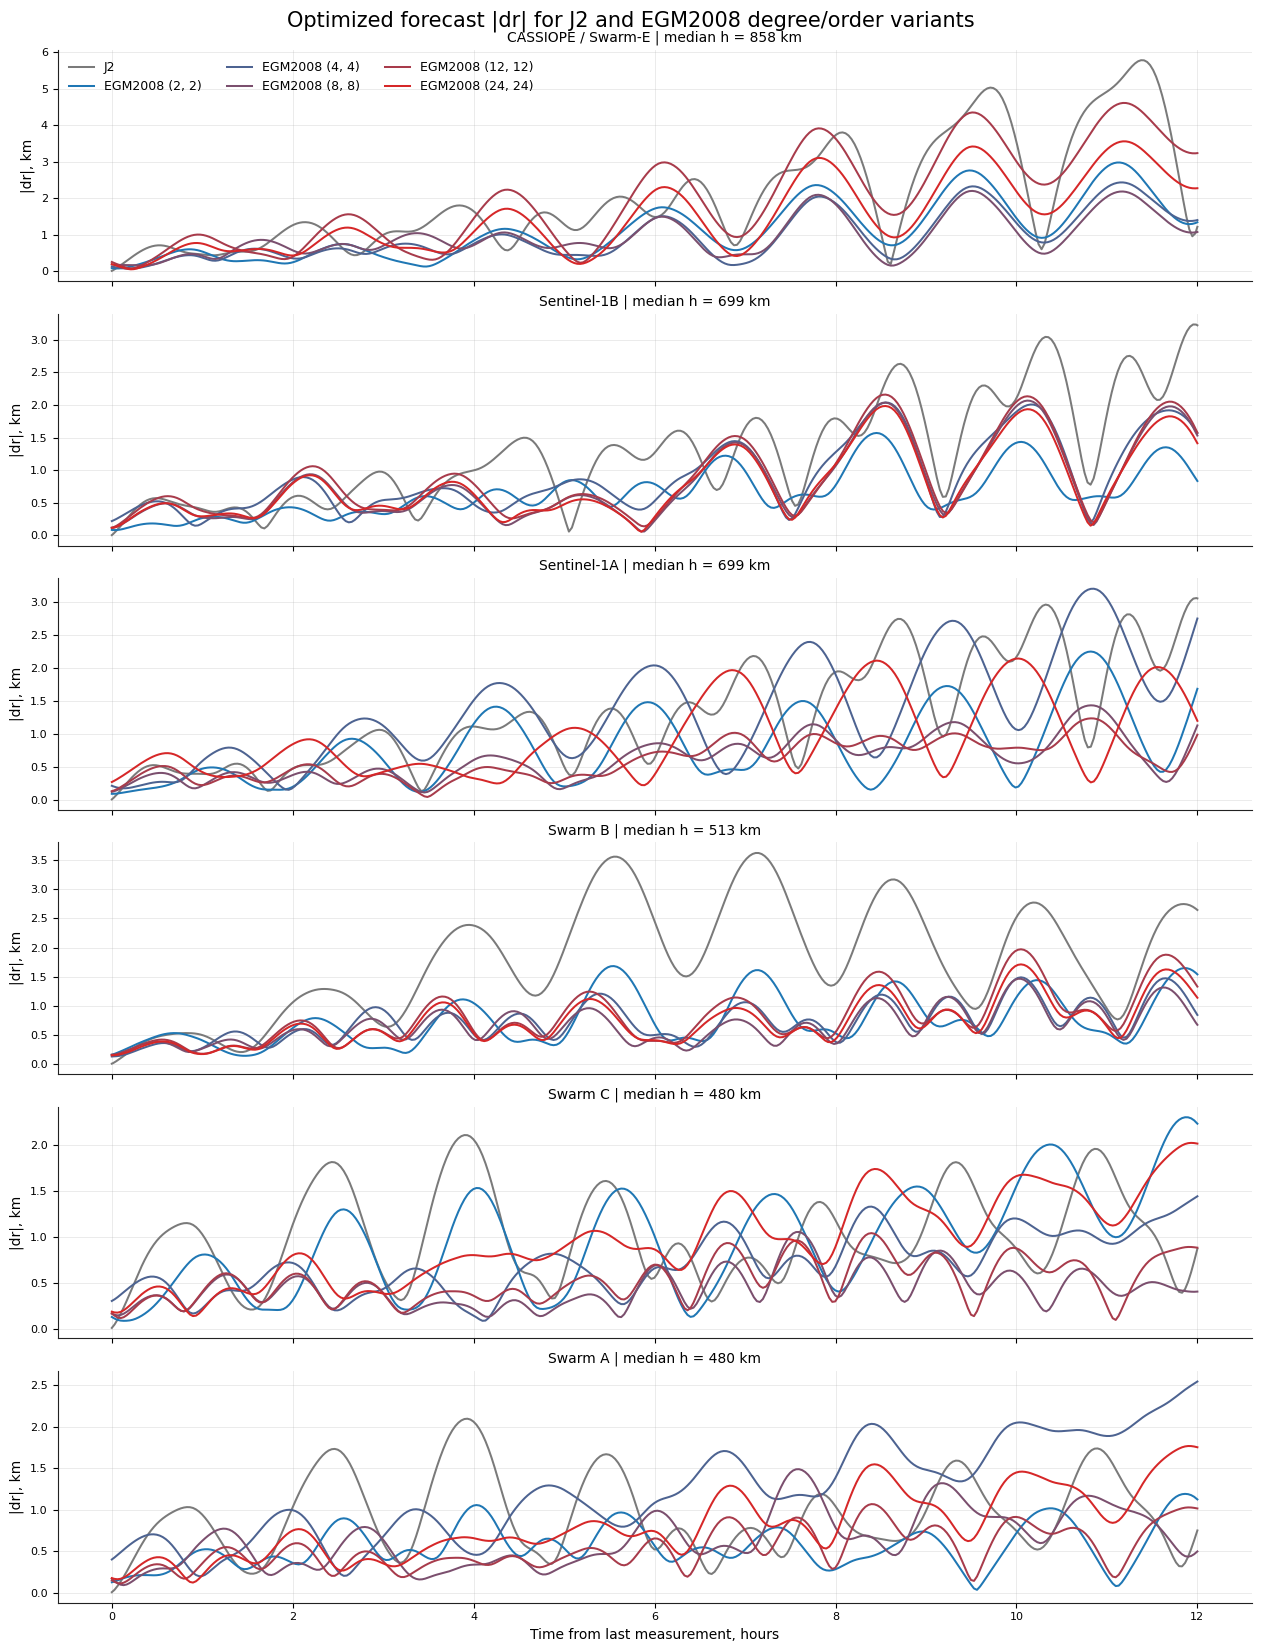

In [22]:

METRIC_ROWS = [
    ('delta_r_norm_km', '|dr|, km'),
    ('delta_radial_km', 'Radial dr, km'),
    ('delta_along_km', 'Along-track dr, km'),
    ('delta_cross_km', 'Cross-track dr, km'),
    ('delta_v_norm_km_s', '|dv|, km/s'),
]

PLOT_STYLE = {
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#222222',
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'font.size': 9,
    'legend.fontsize': 9,
}

MEASUREMENT_COLOR = '#111111'

def plot_gravity_dr_residuals():
    n_sats = len(REFERENCE_CACHE)
    with plt.rc_context({**PLOT_STYLE, 'axes.titlesize': 10, 'font.size': 9}):
        fig, axes = plt.subplots(
            n_sats,
            1,
            figsize=(12.5, 2.7 * n_sats),
            sharex=True,
            constrained_layout=True,
        )
        axes = np.atleast_1d(axes)
        for ax, item in zip(axes, REFERENCE_CACHE):
            for variant_name, results in GRAVITY_RESULTS.items():
                result = results[item['name']]
                ax.plot(
                    (result['model_times_unix'] - float(item['t0_epoch'].unix)) / 3600.0,
                    result['residuals']['delta_r_norm_km'],
                    color=GRAVITY_COLORS[variant_name],
                    lw=1.45,
                    label=variant_name,
                )
            ax.set_title(item['name'] + f' | median h = {item["median_altitude_km"]:.0f} km')
            ax.set_ylabel('|dr|, km')
            ax.grid(True, alpha=0.25, linewidth=0.7)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
        axes[-1].set_xlabel('Time from last measurement, hours')
        axes[0].legend(frameon=False, loc='upper left', ncol=3)
        fig.suptitle('Optimized forecast |dr| for J2 and EGM2008 degree/order variants', fontsize=15, y=1.01)
        plt.show()


plot_gravity_dr_residuals()


Компактный вид показывает среднее и стандартное отклонение прогнозного `|dr|` на 12-часовом горизонте после независимой оптимизации каждого варианта гравитации.

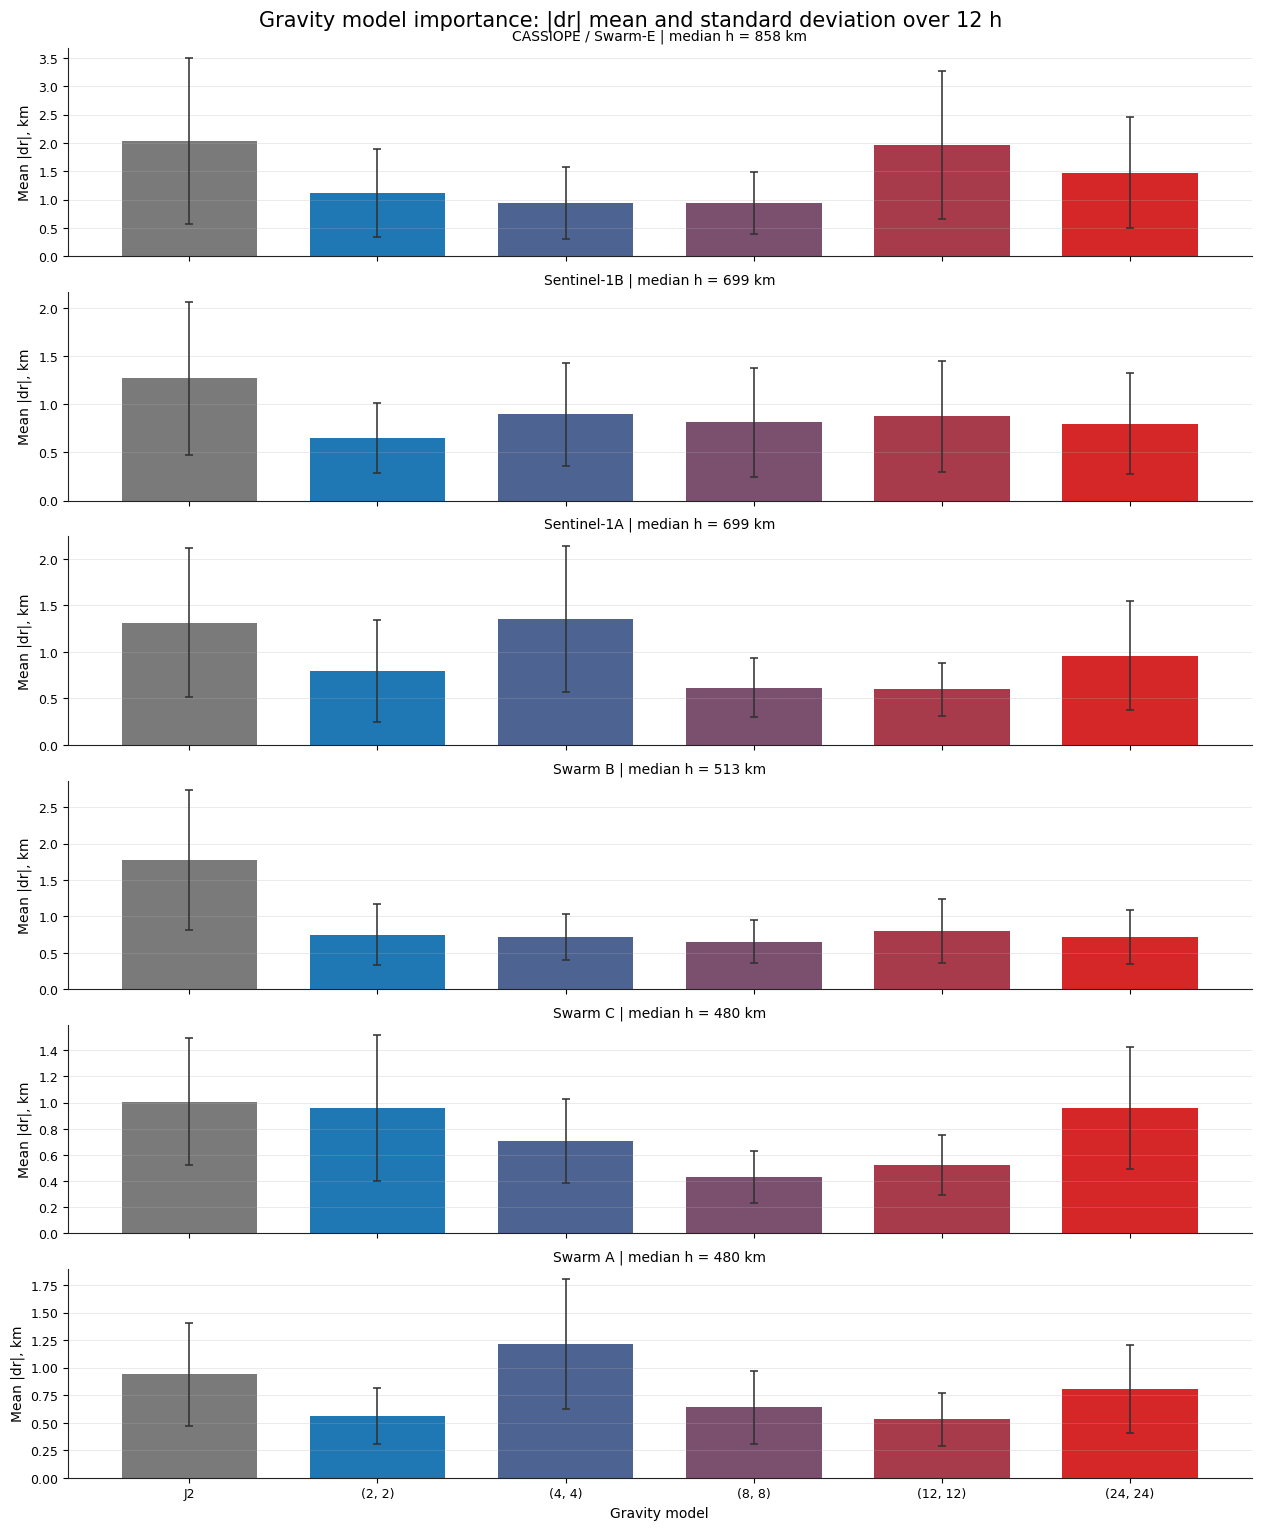

In [23]:

def gravity_variant_tick_label(name):
    if name == 'J2':
        return 'J2'
    return name.replace('EGM2008 ', '')


def plot_gravity_dr_summary():
    variant_names = list(GRAVITY_VARIANTS)
    x = np.arange(len(variant_names), dtype=float)

    with plt.rc_context({**PLOT_STYLE, 'axes.titlesize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9, 'font.size': 10}):
        fig, axes = plt.subplots(
            len(REFERENCE_CACHE),
            1,
            figsize=(12.5, 2.5 * len(REFERENCE_CACHE)),
            sharex=True,
            constrained_layout=True,
        )
        axes = np.atleast_1d(axes)
        for ax, item in zip(axes, REFERENCE_CACHE):
            means = []
            stds = []
            colors = []
            for variant_name in variant_names:
                dr = np.asarray(GRAVITY_RESULTS[variant_name][item['name']]['residuals']['delta_r_norm_km'], dtype=float)
                means.append(np.nanmean(dr))
                stds.append(np.nanstd(dr, ddof=0))
                colors.append(GRAVITY_COLORS[variant_name])
            ax.bar(
                x,
                means,
                yerr=stds,
                width=0.72,
                color=colors,
                alpha=1.0,
                ecolor='#303030',
                error_kw={'elinewidth': 1.4, 'capthick': 1.4, 'alpha': 0.8, 'capsize': 3.0},
                linewidth=0,
            )
            ax.set_title(item['name'] + f' | median h = {item["median_altitude_km"]:.0f} km')
            ax.set_ylabel('Mean |dr|, km')
            ax.grid(True, axis='y', alpha=0.25, linewidth=0.7)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
        axes[-1].set_xticks(x)
        axes[-1].set_xticklabels([gravity_variant_tick_label(name) for name in variant_names])
        axes[-1].set_xlabel('Gravity model')
        fig.suptitle('Gravity model importance: |dr| mean and standard deviation over 12 h', fontsize=15, y=1.01)
        plt.show()


plot_gravity_dr_summary()


## Численная сводка

Эта таблица - компактная проверка воспроизводимости для графиков выше. Расстояния указаны в км; невязки скорости - в км/с.

In [24]:

for row in residual_summary_rows(REFERENCE_CACHE, GRAVITY_RESULTS):
    print(
        f"{row['satellite']} | {row['variant']}: "
        f"mean |dr|={row['mean_dr_km']:.3f} km, std |dr|={row['std_dr_km']:.3f} km, "
        f"final |dr|={row['final_dr_km']:.3f} km, max |dr|={row['max_dr_km']:.3f} km; "
        f"mean |dv|={row['mean_dv_km_s']:.6f} km/s, final |dv|={row['final_dv_km_s']:.6f} km/s, "
        f"max |dv|={row['max_dv_km_s']:.6f} km/s"
    )


CASSIOPE / Swarm-E | J2: mean |dr|=2.035 km, std |dr|=1.470 km, final |dr|=1.214 km, max |dr|=5.783 km; mean |dv|=0.002065 km/s, final |dv|=0.004301 km/s, max |dv|=0.006151 km/s
CASSIOPE / Swarm-E | EGM2008 (2, 2): mean |dr|=1.113 km, std |dr|=0.780 km, final |dr|=1.339 km, max |dr|=2.977 km; mean |dv|=0.001164 km/s, final |dv|=0.001696 km/s, max |dv|=0.002882 km/s
CASSIOPE / Swarm-E | EGM2008 (4, 4): mean |dr|=0.944 km, std |dr|=0.636 km, final |dr|=1.398 km, max |dr|=2.431 km; mean |dv|=0.000933 km/s, final |dv|=0.001596 km/s, max |dv|=0.002454 km/s
CASSIOPE / Swarm-E | EGM2008 (8, 8): mean |dr|=0.945 km, std |dr|=0.546 km, final |dr|=1.072 km, max |dr|=2.198 km; mean |dv|=0.000879 km/s, final |dv|=0.001306 km/s, max |dv|=0.002169 km/s
CASSIOPE / Swarm-E | EGM2008 (12, 12): mean |dr|=1.964 km, std |dr|=1.306 km, final |dr|=3.235 km, max |dr|=4.610 km; mean |dv|=0.002043 km/s, final |dv|=0.003415 km/s, max |dv|=0.004871 km/s
CASSIOPE / Swarm-E | EGM2008 (24, 24): mean |dr|=1.477 km, s

## Замечания и ограничения

* Исходные эталонные данные в `data` являются входными данными только для чтения; этот ноутбук их не изменяет.
* Все варианты используют NRLMSISE-00 и одинаковые настройки негравитационных сил.
* Масштабные коэффициенты сил для гармоник гравитации и ускорений третьих тел оптимизируются как в ноутбуке MIPT-forces. Это может частично компенсировать ошибки усечения, поэтому интерпретируйте результаты как эффективность текущего оптимизированного workflow, а не как чистый бюджет ошибки гравитационного поля.
* Время выполнения управляется `RUN_SATELLITES` и `EGM2008_DEGREE_ORDER_VARIANTS`. Для быстрых проверок сократите один из этих списков перед запуском полного эксперимента.